# Домашнє завдання: Візуалізація даних з Matplotlib

## Опис завдання
У цьому домашньому завданні ви продовжите працювати з датасетом про оренду велосипедів `yulu_rental.csv`, але тепер будете використовувати бібліотеку Matplotlib для створення більш складних та налаштованих візуалізацій.

**Опис колонок:**
- `datetime` - дата та час
- `season` - квартал (1-Q1, 2-Q2, 3-Q3, 4-Q4)
- `holiday` - чи є день святковим (0=ні, 1=так)
- `workingday` - чи є день робочим (0=ні, 1=так)
- `weather` - погодні умови (1=ясно, 2=туман, 3=легкий дощ, 4=сильний дощ)
- `temp` - температура в градусах Цельсія
- `atemp` - відчувається як температура
- `humidity` - вологість (%)
- `windspeed` - швидкість вітру
- `casual` - кількість випадкових користувачів
- `registered` - кількість зареєстрованих користувачів
- `count` - загальна кількість орендованих велосипедів

## Підготовка даних

---


🌱 Коментар щодо сезонності

Колонка season у датасеті представляє саме квартали року, а не метеорологічні сезони. Тому всі аналізи сезонності ви можете будувати на основі кварталів.

Водночас дані були зібрані в Індії, де поділ на сезони інший, ніж у Європі чи США. Якщо ви хочете дослідити сезонність відповідно до індійської системи сезонів, можна створити окрему колонку.

Справжні сезони в Індії:

| Сезон        | Місяці                     |
| ------------ | -------------------------- |
| Winter       | December–February (12,1,2) |
| Summer       | March–May (3,4,5)          |
| Monsoon      | June–September (6,7,8,9)   |
| Post-monsoon | October–November (10,11)   |


Тоді потрібно зробити нову колонку weather_season_india, мапнувши місяці так:

12, 1, 2 → 1 (Winter)

3, 4, 5 → 2 (Summer)

6–9 → 3 (Monsoon)

10–11 → 4 (Post-Monsoon)

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Завантаження даних
df = pd.read_csv('yulu_rental.csv')
df['datetime'] = pd.to_datetime(df['datetime'])
df.set_index('datetime', inplace=True)

# Додаткові колонки
df['month'] = df.index.month
df['hour'] = df.index.hour
df['weekday'] = df.index.day_name()
df['weekday_num'] = df.index.weekday
df['week'] = df.index.isocalendar().week
df['year'] = df.index.year
df['day'] = df.index.day

## Завдання 1: Порівняння Pandas vs Matplotlib

**Завдання:**
Побудуйте лінійний графік середньої кількості оренд помісячно впродовж всього періоду в даних двома способами:
1. Використовуючи Pandas (DataFrame.plot())
2. Використовуючи Matplotlib безпосередньо

В обох методах додайте маркери-кружечки. Можна також задати свій відмінний від стандартного колір.

Підказка: отримати потрібний формат даних найзручніше з методом датафрейму `resample`.

**Опишіть свої спостереження:** чим відрізняються 2 побудованих графіки? Який вам більше подобається?

In [2]:
mean_count_by_month = df['count'].resample('ME').mean()
mean_count_by_month

,count
datetime,
2011-01-31,54.645012
2011-02-28,73.641256
2011-03-31,86.849776
2011-04-30,111.026374
2011-05-31,174.809211
2011-06-30,196.877193
2011-07-31,203.614035
2011-08-31,182.666667
2011-09-30,174.622517


<Axes: title={'center': 'Середня кількість оренди велосипедів по місяцях'}, xlabel='Місяць', ylabel='Середня кількість оренди велосипедів'>

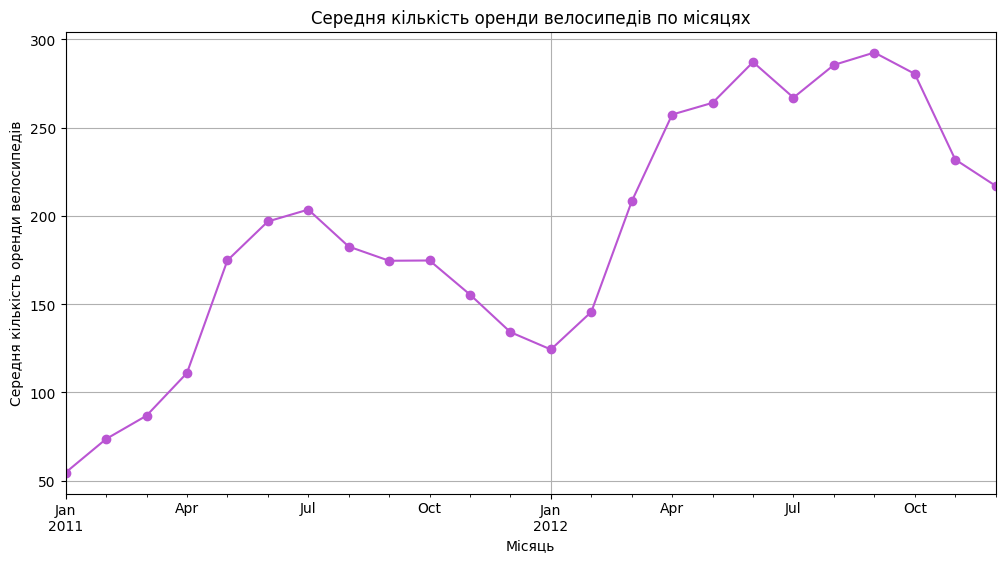

In [3]:
mean_count_by_month.plot.line(
    figsize=(12, 6),
    marker='o',
    title='Середня кількість оренди велосипедів по місяцях',
    xlabel='Місяць',
    ylabel='Середня кількість оренди велосипедів',
    grid=True,
    color='mediumorchid',
)

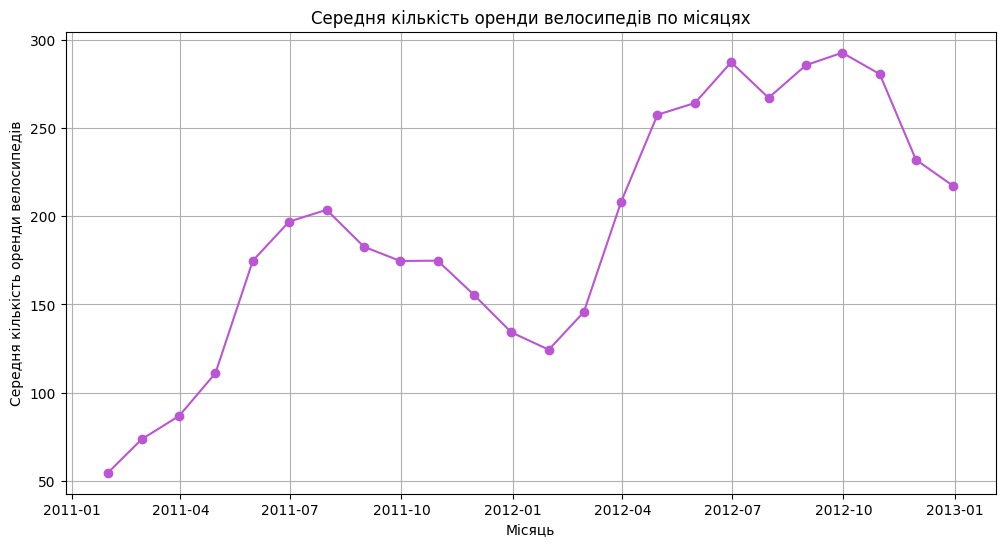

In [4]:
plt.figure(figsize=(12, 6))
plt.plot(mean_count_by_month, 'o-', color='mediumorchid')
plt.title('Середня кількість оренди велосипедів по місяцях')
plt.xlabel('Місяць')
plt.ylabel('Середня кількість оренди велосипедів')
plt.grid(True);

чим відрізняються 2 побудованих графіки? Який вам більше подобається?

## Завдання 2: Робота зі списками та numpy

**Завдання:**
Вам задані 3 списки:
1. Номер дня тижня.
2. Продажі в тиждень 1.
3. Продажі в тиждень 2.

Створіть графік, на якому лінійними графіками різних кольорів накладено продажі за обидва тижні.

Обовʼязково додайте назву графіку, підписи вісям ОХ, ОУ, назви кожного з рядів даних, легенду.

**Дайте відповіді на питання**
1. Судячи з графіку, в який тиждень продажі були стабільніше?
2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

In [5]:
# Дані у вигляді списків
days = [1, 2, 3, 4, 5, 6, 7] # 1 - це понеділок
sales_week1 = [1349,1562,1600,1606,1510,959,822]  # Продажі за тиждень1
sales_week2 = [1321,1263,1162,1406,1421,1248,1204]  # Продажі за тиждень1

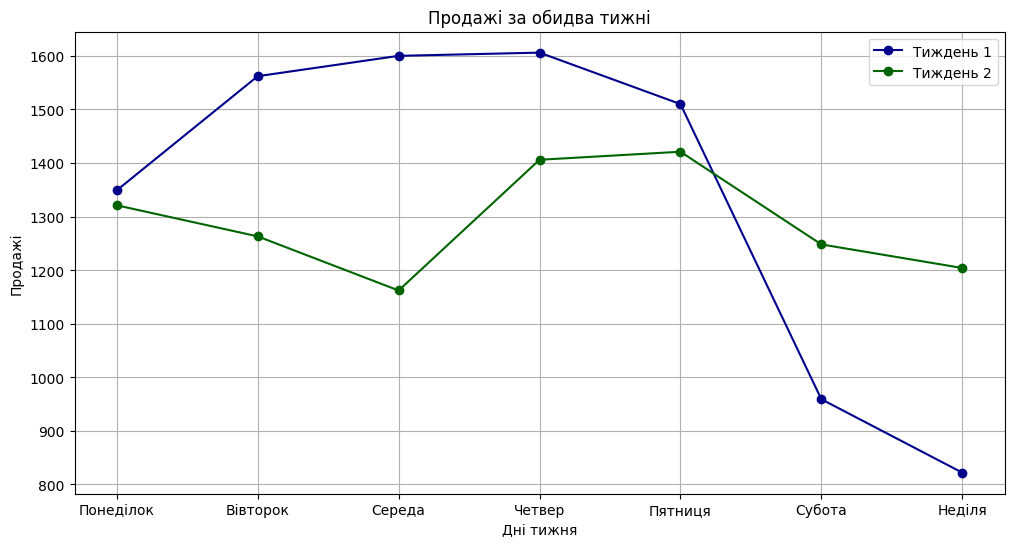

In [6]:
plt.figure(figsize=(12, 6))
plt.plot(days, sales_week1, 'o-', color='darkblue')
plt.plot(days, sales_week2, 'o-', color='darkgreen')
plt.title('Продажі за обидва тижні')
plt.xlabel('Дні тижня')
plt.xticks(range(1, 8), ['Понеділок', 'Вівторок', 'Середа', 'Четвер', 'Пятниця', 'Субота', 'Неділя'])
plt.ylabel('Продажі')
plt.grid(True)
plt.legend(['Тиждень 1', 'Тиждень 2'])
plt.show()

1. Судячи з графіку, в який тиждень продажі були стабільніше?

Продажі були стабільніші на другому тижні.

2. Чи можете ви підкріпити свій висновок обчисленнями? Якими саме? Можна (але не обовʼязково) навести ці обчислення.

Стабільність продажів можна перевірити розрахувавши середнє значення, стандартне відхилення та коефіцієнт кореляції. Відповідно до результатів значення середнього, стандартного відхилення, коефіцієнту кореляції для другого тижня менше, ніж для першого тижня. Отже, продажі були стабільніші на другому тижні.

In [7]:
import numpy as np
print(f"Середнє (тиждень 1) = {np.mean(sales_week1):.3f}\nСереднє (тиждень 2) = {np.mean(sales_week2):.3f}")
print(f"Стандартне відхилення (тиждень 1) = {np.std(sales_week1):.3f}\nСтандартне відхилення (тиждень 2) = {np.std(sales_week2):.3f}")
print(f"Коефіцієнт кореляції (тиждень 1) = {np.std(sales_week1)/np.mean(sales_week1):.3f}\nКоефіцієнт кореляції (тиждень 2) = {np.std(sales_week2)/np.mean(sales_week2):.3f}")

Середнє (тиждень 1) = 1344.000
Середнє (тиждень 2) = 1289.286
Стандартне відхилення (тиждень 1) = 299.999
Стандартне відхилення (тиждень 2) = 90.906
Коефіцієнт кореляції (тиждень 1) = 0.223
Коефіцієнт кореляції (тиждень 2) = 0.071


## Завдання 3: Subplot - 2x2 сітка графіків

**Завдання:**
Створіть сітку 2x2 з чотирма різними графіками, використовуючи `plt.subplot()`:
1. Лінійний графік середньої температури помісячно.
2. Стовпчикова діаграма середньої годинної кількості оренд за кварталами.
3. Гістограма вологості за всіма погодинними вимірами.
4. Scatter plot температури vs кількості оренд.

Кожен підграфік має містити всі необхідні підписи. Дашборд має містити назву.

In [8]:
temp_by_month = df.groupby('month')['temp'].mean()
temp_by_month

,temp
month,
1,9.840000
2,11.798535
3,15.902175
4,18.718372
5,22.674079
6,27.064496
7,30.841711
8,29.736689
9,25.779032


In [9]:
count_by_season = df.groupby('season')['count'].sum()
count_by_season

,count
season,
1,312498
2,588282
3,640662
4,544034


In [10]:
count_by_temp = df.groupby('temp')['count'].sum()
count_by_temp

,count
temp,
0.82,544
1.64,183
2.46,215
3.28,212
4.10,2212
4.92,3505
5.74,5696
6.56,9944
7.38,7182


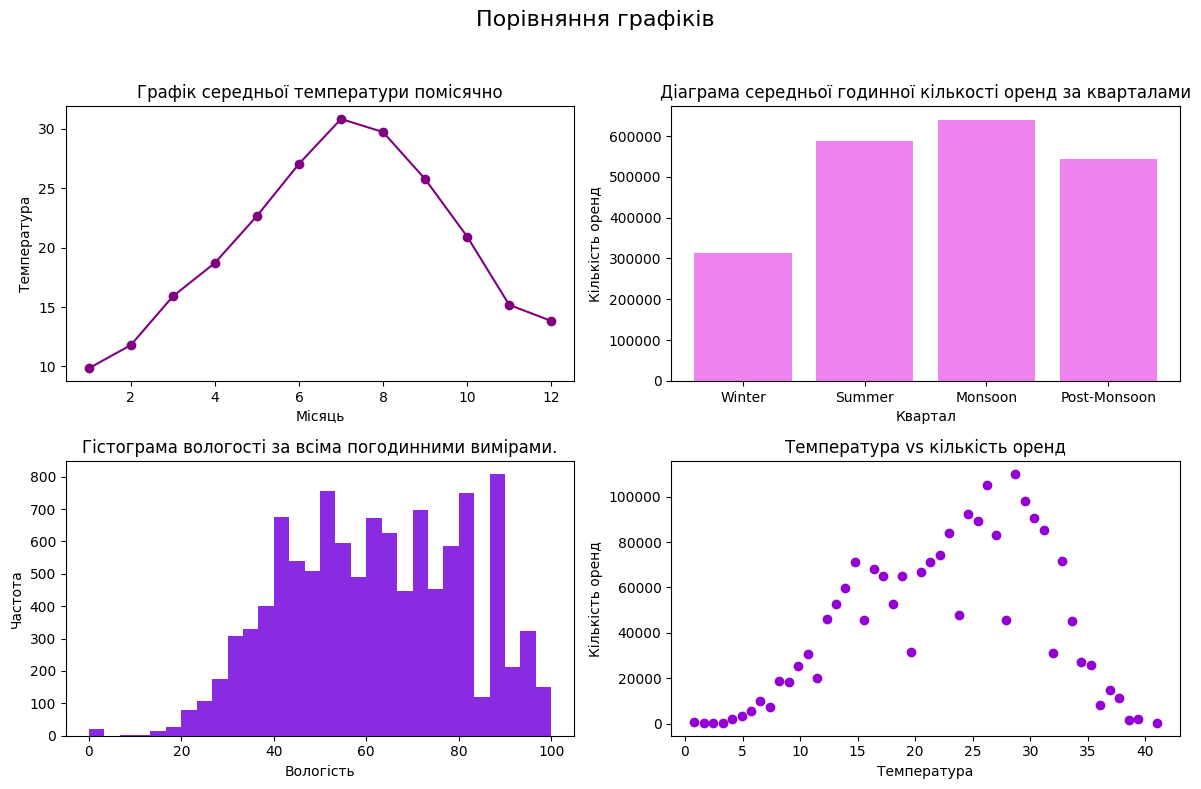

In [11]:
plt.figure(figsize=(12, 8))

# Графік 1
plt.subplot(2, 2, 1)
plt.plot(temp_by_month, 'o-', color='purple')
plt.title('Графік середньої температури помісячно')
plt.xlabel('Місяць')
plt.ylabel('Температура')

# Графік 2
plt.subplot(2, 2, 2)
plt.bar(count_by_season.index, count_by_season.values, color='violet')
plt.title('Діаграма середньої годинної кількості оренд за кварталами')
plt.xlabel('Квартал')
plt.xticks(range(1, 5), ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])
plt.ylabel('Кількість оренд')

# Графік 3
plt.subplot(2, 2, 3)
plt.hist(df['humidity'].dropna(), bins=30, color='blueviolet')
plt.title('Гістограма вологості за всіма погодинними вимірами.')
plt.xlabel('Вологість')
plt.ylabel('Частота')

# Графік 4
plt.subplot(2, 2, 4)
plt.plot(count_by_temp, 'o', color='darkviolet')
plt.title('Температура vs кількість оренд')
plt.xlabel('Температура')
plt.ylabel('Кількість оренд')

# Загальний вигляд
plt.suptitle('Порівняння графіків', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

## Завдання 4: Subplots - об'єктно-орієнтований підхід

**Завдання:**
Створіть той самий набір графіків, але використовуючи `fig, ax = plt.subplots()`.

**Дайте відповідь на питання своїми словами**
- Чим відрізняється підхід побудови кількох графіків на одній фігурі з `plt.subplots()` від `plt.subplot()`?

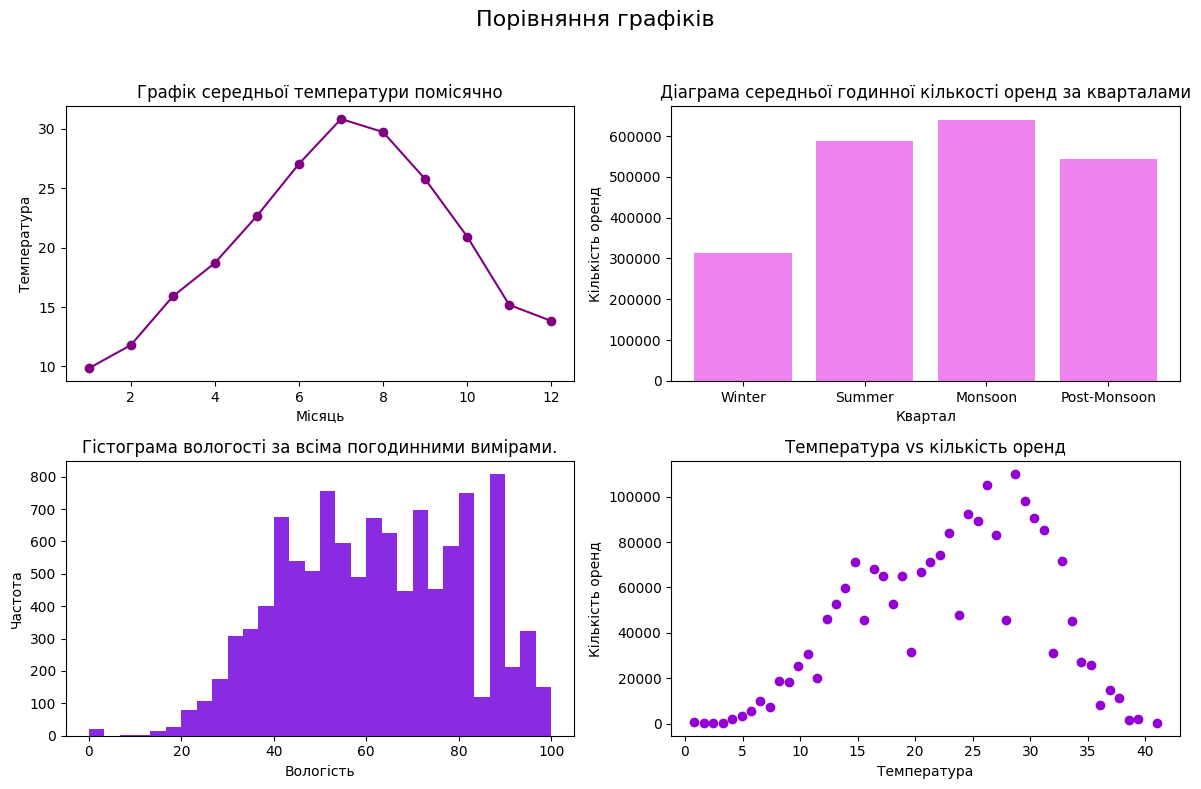

In [12]:
fig, ax = plt.subplots(2, 2, figsize=(12, 8))

# Графік 1
ax[0, 0].plot(temp_by_month, 'o-', color='purple')
ax[0, 0].set_title('Графік середньої температури помісячно')
ax[0, 0].set_xlabel('Місяць')
ax[0, 0].set_ylabel('Температура')

# Графік 2
ax[0, 1].bar(count_by_season.index, count_by_season.values, color='violet')
ax[0, 1].set_title('Діаграма середньої годинної кількості оренд за кварталами')
ax[0, 1].set_xlabel('Квартал')
ax[0, 1].set_xticks(range(1, 5), ['Winter', 'Summer', 'Monsoon', 'Post-Monsoon'])
ax[0, 1].set_ylabel('Кількість оренд')

# Графік 3
ax[1, 0].hist(df['humidity'].dropna(), bins=30, color='blueviolet')
ax[1, 0].set_title('Гістограма вологості за всіма погодинними вимірами.')
ax[1, 0].set_xlabel('Вологість')
ax[1, 0].set_ylabel('Частота')

# Графік 4
ax[1, 1].plot(count_by_temp, 'o', color='darkviolet')
ax[1, 1].set_title('Температура vs кількість оренд')
ax[1, 1].set_xlabel('Температура')
ax[1, 1].set_ylabel('Кількість оренд')

# Загальний вигляд
fig.suptitle('Порівняння графіків', fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.95])  # залишаємо місце для заголовка
plt.show()

Чим відрізняється підхід побудови кількох графіків на одній фігурі з plt.subplots() від plt.subplot()?

plt.subplots() більш гнучкий підхід для побудови графіків, але синтаксис plt.subplots() - більш складний. plt.subplot() - більш швидкий спосіб для побудови графіків, але більше 4 графіків і код стає складнішим для читання.

## (Опціонально) Завдання 5: Тонкі налаштування форматування графіка

**Завдання:**
Подібно до прикладу, наведеного в лекції, створіть професійно оформлений графік помісячної динаміки оренди з максимальною кількістю деталей та налаштувань. Ваш графік має включати:

**Обов'язкові елементи:**
1. **Три лінії:** середнє, максимум, мінімум за місяцями
2. **Різні стилі ліній:** суцільна, пунктирна, крапкова + різні маркери
3. **Заливка області** між мінімумом та максимумом
4. **Дві анотації:** для найвищого та найнижчого середнього значення
5. **Горизонтальна лінія** середнього за весь рік
6. **Двошарова сітка:** основна та допоміжна
7. **Стилізована легенда** з тінню
8. **Текстовий блок** зі статистикою в кутку графіка
9. **Професійне оформлення:** заголовки, підписи осей з жирним шрифтом

**Результат:** Графік повинен виглядати як готова ілюстрація для бізнес-звіту або наукової публікації.

Приклад очікуваного результату.
![](https://drive.google.com/uc?id=1YoJByivzlqncEF2zbWu3EhGSZ7XRme8T)


**Питання для інтерпретації:**
1. Яка перевага додавання анотацій на графік?
2. Для чого використовується fill_between()?
3. Як текстовий блок допомагає в інтерпретації даних?

In [13]:
count_by_month = df['count'].resample('ME').agg(['mean','min','max'])
count_by_month

,mean,min,max
datetime,,,
2011-01-31,54.645012,1,219
2011-02-28,73.641256,1,327
2011-03-31,86.849776,1,332
2011-04-30,111.026374,1,452
2011-05-31,174.809211,1,611
2011-06-30,196.877193,1,638
2011-07-31,203.614035,1,596
2011-08-31,182.666667,1,600
2011-09-30,174.622517,1,628


In [14]:
import matplotlib.dates as mdates

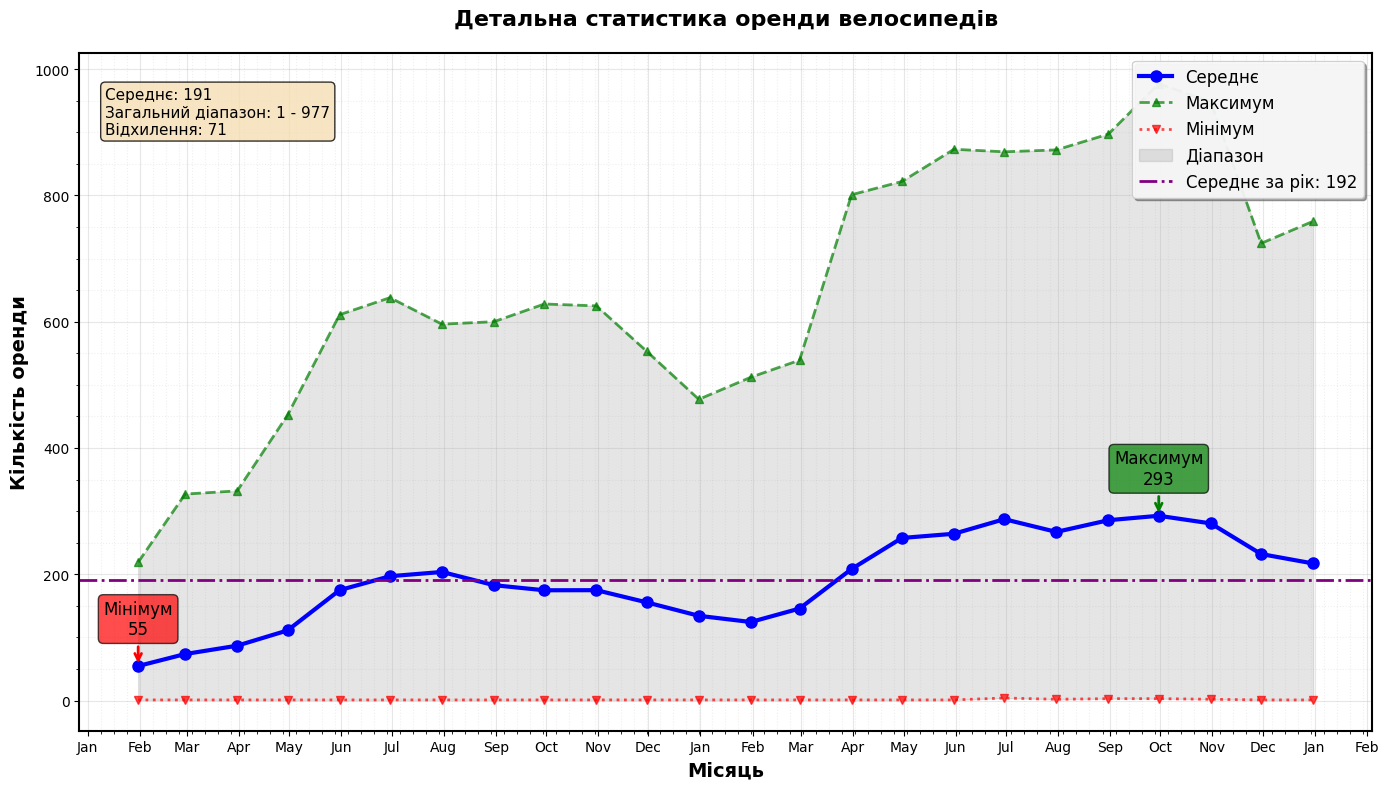

In [15]:
fig, ax = plt.subplots(figsize=(14, 8))

# Малюємо лінії з різними стилями
ax.plot(count_by_month.index, count_by_month['mean'], 'b-o', linewidth=3,
        label='Середнє', markersize=8)
ax.plot(count_by_month.index, count_by_month['max'], 'g--^', linewidth=2,
        label='Максимум', markersize=6, alpha=0.7)
ax.plot(count_by_month.index, count_by_month['min'], 'r:v', linewidth=2,
        label='Мінімум', markersize=6, alpha=0.7)

# Заливка між max та min (правильний синтаксис)
ax.fill_between(count_by_month.index, count_by_month['min'], count_by_month['max'],
                alpha=0.2, color='gray', label='Діапазон')

# Додаємо анотації для екстремальних значень
max_idx = count_by_month['mean'].idxmax()
max_val = count_by_month['mean'].max()
ax.annotate(f'Максимум\n{max_val:.0f}',
            xy=(max_idx, max_val), xytext=(max_idx, max_val + 50),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='green', alpha=0.7))
min_idx = count_by_month['mean'].idxmin()
min_val = count_by_month['mean'].min()
ax.annotate(f'Мінімум\n{min_val:.0f}',
            xy=(min_idx, min_val), xytext=(min_idx, min_val + 50),
            arrowprops=dict(arrowstyle='->', color='red', lw=2),
            fontsize=12, ha='center',
            bbox=dict(boxstyle="round,pad=0.3", facecolor='red', alpha=0.7))

# Налаштування осей
ax.set_xlabel('Місяць', fontsize=14, fontweight='bold')
ax.set_ylabel('Кількість оренди', fontsize=14, fontweight='bold')
ax.set_title('Детальна статистика оренди велосипедів',
             fontsize=16, fontweight='bold', pad=20)

# Форматування дат на осі X
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b'))
ax.xaxis.set_major_locator(mdates.MonthLocator())

# Додаємо сітку з різними стилями
ax.grid(True, which='major', linestyle='-', alpha=0.3)
ax.grid(True, which='minor', linestyle=':', alpha=0.2)
ax.minorticks_on()

# Додаємо середню лінію за весь період
overall_mean = df['count'].mean()
ax.axhline(y=overall_mean, color='purple', linestyle='-.', linewidth=2,
           label=f'Середнє за рік: {overall_mean:.0f}')

# Покращуємо легенду
ax.legend(loc='upper right', fontsize=12, frameon=True, shadow=True,
          fancybox=True, framealpha=0.9)

# Додаємо текст з додатковою статистикою
textstr = f'Середнє: {count_by_month["mean"].mean():.0f}\n'
textstr += f'Загальний діапазон: {count_by_month["min"].min():.0f} - {count_by_month["max"].max():.0f}\n'
textstr += f'Відхилення: {count_by_month["mean"].std():.0f}'
props = dict(boxstyle='round', facecolor='wheat', alpha=0.8)
ax.text(0.02, 0.95, textstr, transform=ax.transAxes, fontsize=11,
        verticalalignment='top', bbox=props)

# Налаштування рамки
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
plt.show()

1. Яка перевага додавання анотацій на графік?

Перевага додавання анотацій на графік в тому, що графік стає легшим для розуміння, можна одразу побачити основні показники.

2. Для чого використовується fill_between()?

Для заливки графіка між значеннями прямої мінімуму та значеннями прямої максимуму.

3. Як текстовий блок допомагає в інтерпретації даних?

Анотації для екстремальних даних, додаткова статистика, легенда допомагають одразу побачити основні показники, не проводячи додаткових досліджень, і як наслідок швидше зробити висновки та відповісти на питання, щодо датасету.